## kaggle dataset import
https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017/data

In [30]:
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("martj42/international-football-results-from-1872-to-2017")
print(path)
print(os.listdir(path))

df = pd.read_csv(os.path.join(path, "results.csv"))
df.head()


C:\Users\ARW\.cache\kagglehub\datasets\martj42\international-football-results-from-1872-to-2017\versions\129
['former_names.csv', 'goalscorers.csv', 'results.csv', 'shootouts.csv']


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [31]:
print(df.info())
df.head()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 49494 entries, 0 to 49493
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49494 non-null  str    
 1   home_team   49494 non-null  str    
 2   away_team   49494 non-null  str    
 3   home_score  49481 non-null  float64
 4   away_score  49481 non-null  float64
 5   tournament  49494 non-null  str    
 6   city        49494 non-null  str    
 7   country     49494 non-null  str    
 8   neutral     49494 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB
None


Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral'],
      dtype='str')

In [32]:
df["tournament"].value_counts().head(20)

tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1053
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Gold Cup                                  420
Gulf Cup                                  410
Island Games                              394
UEFA Euro                                 388
Asian Games                               368
Name: count, dtype: int64

## build target variable

In [74]:
# convert to home score results
import numpy as np

df["result"] = np.where(df["home_score"] > df["away_score"], 2,   # home win
               np.where(df["home_score"] == df["away_score"], 1,  # draw
                0)) # home loss
print(df["result"].value_counts(normalize=True).mul(100).round(2)) # percentage of each result


result
2    48.99
0    28.27
1    22.74
Name: proportion, dtype: float64


In [75]:
# sorted chronologically

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df[["date","home_team","away_team", "result"]].head()

,date,home_team,away_team,result
0,1872-11-30,Scotland,England,1
1,1873-03-08,England,Scotland,2
2,1874-03-07,Scotland,England,2
3,1875-03-06,England,Scotland,1
4,1876-03-04,Scotland,England,2


In [76]:
print(df["date"].min())
print(df["date"].max())

1872-11-30 00:00:00
2026-07-04 00:00:00


## elo calculation

We first calculate the ELO ratings from the kaggle dataset, using FIFA's SUM system based on match importance factor, elo scores before match, and resultant vs expected elo scores. In the end we want something like:

| date       | home_team | away_team | home_elo | away_elo | result |
| ---------- | --------- | --------- | -------- | -------- | ------ |
| 1950-07-16 | Brazil    | Uruguay   | 1832     | 1798     | loss   |


references: 
- https://digitalhub.fifa.com/m/f99da4f73212220/original/edbm045h0udbwkqew35a-pdf.pdf
- https://fifarankingcalculator.com/
- https://worldfootballrankings.com/methodology

In [53]:
# simple model first
INITIAL_ELO = 1500
from collections import defaultdict
ratings = defaultdict(lambda: 1500)
ratings["England"]

1500

Expected elo score:
$$E_A = 1 / {1+10^{(R_B-R_A)/400}}$$
$$E_B = 1 - E_A$$

Actual score: win=1, draw=0.5, loss=0.

Updated elo score:
$$R_A′=R_A + K (S_A − E_A)$$
$$R_B′=R_B + K (S_B - E_B)$$

In [61]:
K = 30 # initial K-factor
home_elos = [] # containers
away_elos = []

# iterate through each match
for _, row in df.iterrows():
    home = row["home_team"]
    away = row["away_team"]

    # calculate current ratings for home and away teams RA, RB
    home_rating = ratings[home]
    away_rating = ratings[away]

    # store PRE-MATCH ratings
    home_elos.append(home_rating)
    away_elos.append(away_rating)

    # apply formula to calculate EA, EB
    expected_home = 1 / (1 + 10 ** ((away_rating - home_rating) / 400))
    expected_away = 1 - expected_home

    # calculate actual result SA, SB
    if row["home_score"] > row["away_score"]:
        actual_home = 1
        actual_away = 0

    elif row["home_score"] < row["away_score"]:
        actual_home = 0
        actual_away = 1

    else:
        actual_home = 0.5
        actual_away = 0.5

    # updated RA', RB'
    ratings[home] = (home_rating + K * (actual_home - expected_home))
    ratings[away] = (away_rating + K * (actual_away - expected_away))


df["home_elo"] = home_elos
df["away_elo"] = away_elos

In [68]:
# check tail of the dataframe
df[["date", "home_team", "away_team", "home_elo", "away_elo"]].tail(10)

,date,home_team,away_team,home_elo,away_elo
49484,2026-07-01,England,DR Congo,2005.911845,1712.405566
49485,2026-07-01,Belgium,Senegal,1934.587623,1831.549998
49486,2026-07-01,United States,Bosnia and Herzegovina,1859.424801,1698.669747
49487,2026-07-02,Spain,Austria,2101.003735,1895.323777
49488,2026-07-02,Portugal,Croatia,2005.591487,1943.148985
49489,2026-07-02,Switzerland,Algeria,1914.775578,1855.296559
49490,2026-07-03,Australia,Egypt,1828.103394,1792.228109
49491,2026-07-03,Argentina,Cape Verde,2110.551169,1656.745322
49492,2026-07-03,Colombia,Ghana,1987.555147,1619.768994
49493,2026-07-04,Canada,Morocco,1840.929249,1950.521702


count    49494.000000
mean        12.764991
std        211.017886
min      -1072.193170
25%       -119.482702
50%         12.928949
75%        146.058090
max       1062.834282
Name: elo_diff, dtype: float64


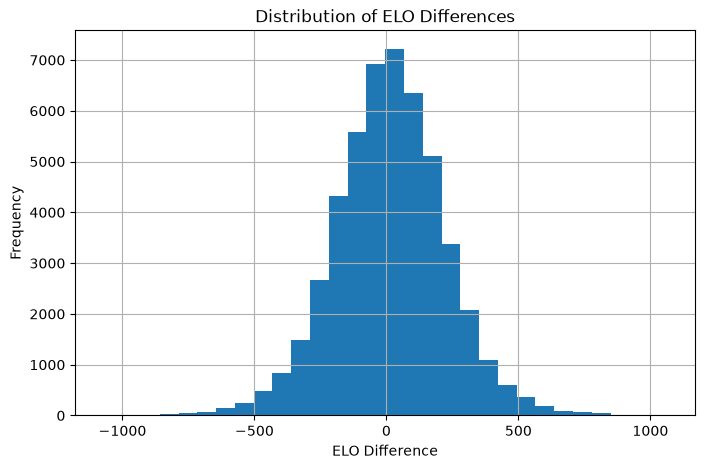

In [72]:
df["elo_diff"] = (df["home_elo"] - df["away_elo"])
print(df["elo_diff"].describe())

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(df["elo_diff"], bins=30)
plt.xlabel("ELO Difference")
plt.ylabel("Frequency")
plt.title("Distribution of ELO Differences")
plt.grid(True)
plt.show()

## train logistic regression

In [ ]:
# features
X = df[["elo_diff"]]

# targets
y = df["result"]

# train/test split:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)